## Your API key (30 seconds)

The course model runs on OpenRouter. Give this notebook your issued key in one of two ways:

- **Recommended:** click the key icon in Colab's left sidebar, add a secret named
  `OPENROUTER_API_KEY`, and switch on *Notebook access*. Every course notebook then finds it automatically.
- **Or:** run the cell below and paste the key when asked (it is kept only in this session).

No key? Just press Enter when asked. The notebook switches to the mock model and everything still runs.
Never paste a key into a code cell: notebooks get shared.

In [ ]:
# === Setup: run this cell first ===============================================
# It reads your API key, creates the client, and defines chat(): the ONE function
# every reviewer in this notebook uses to talk to the model.
import json, os, re
from getpass import getpass

MODEL = "openai/gpt-oss-120b"          # the course model on OpenRouter

def load_api_key():
    """Look for the key in Colab Secrets, then the environment, then ask once."""
    try:
        from google.colab import userdata           # only exists on Colab
        key = userdata.get("OPENROUTER_API_KEY")
        if key:
            return key, "Colab secret"
    except Exception:
        pass                                        # not on Colab, or no secret yet
    if os.getenv("OPENROUTER_API_KEY"):
        return os.environ["OPENROUTER_API_KEY"], "environment variable"
    try:
        key = getpass("OpenRouter API key (press Enter to use the mock model): ").strip()
    except Exception:                               # no keyboard available (automated run)
        key = ""
    return (key, "typed in") if key else ("", "none")

API_KEY, KEY_SOURCE = load_api_key()
LIVE = bool(API_KEY)                                # True = real model, False = mock model
client = None
if LIVE:
    from openai import OpenAI                       # the OpenAI SDK speaks OpenRouter's API too
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=API_KEY)

def chat(messages, tools=None, response_format=None, temperature=0.0, max_tokens=1200):
    """Send ONE request to the model and return a plain dict:
         {"content": str, "tool_calls": [...], "usage": {...}}
    Every reviewer today is a call to this function plus validation of what came back."""
    if not LIVE:
        return mock_model(messages, tools, response_format)
    request = dict(model=MODEL, messages=messages, temperature=temperature, max_tokens=max_tokens,
                   extra_body={"reasoning": {"effort": "low"}})   # keep hidden reasoning short and cheap
    if tools:
        request["tools"] = tools
    if response_format:
        request["response_format"] = response_format
    response = client.chat.completions.create(**request)
    message = response.choices[0].message
    calls = [{"id": call.id, "name": call.function.name,
              "arguments": json.loads(call.function.arguments or "{}")}
             for call in (message.tool_calls or [])]
    usage = response.usage
    return {"content": message.content or "", "tool_calls": calls,
            "usage": {"prompt_tokens": usage.prompt_tokens, "completion_tokens": usage.completion_tokens,
                      "total_tokens": usage.total_tokens}}

print("Model  :", MODEL)
print("Key    :", KEY_SOURCE)
print("Mode   :", "LIVE - real model replies" if LIVE else "MOCK - scripted replies, real shapes, zero cost")

### The mock model (read later, or never)

Without a key, `chat()` hands the request to the function below. Every request today is one kind —
"review this file" — so the mock answers with a **scripted reviewer** returning the JSON a real
model would. Its rules arrive in 4.2, after you have read the artifact yourself.

In [ ]:
MOCK_SCENARIO = "blind_spots"       # which blind spots the scripted reviewer has (section 4.2)

def _mock_reply(content="", prompt_chars=0):
    """Reply in exactly the shape chat() returns, with an honest usage estimate.
    A mock still reports usage: roughly 4 characters per token, not an invented number."""
    prompt_tokens = (prompt_chars + 3) // 4
    completion_tokens = (len(content) + 3) // 4
    return {"content": content, "tool_calls": [],
            "usage": {"prompt_tokens": prompt_tokens, "completion_tokens": completion_tokens,
                      "total_tokens": prompt_tokens + completion_tokens}}

def review_request(messages):
    """Pull (role, artifact text) out of a review request. The request is built in 4.2:
    the system message carries 'Role: <name>' and the user message is a header then the file."""
    system = " ".join(m["content"] for m in messages if m["role"] == "system")
    user = next((m["content"] for m in reversed(messages) if m["role"] == "user"), "")
    match = re.search(r"Role:\s*(\w+)", system)
    return (match.group(1), user.split("\n\n", 1)[-1]) if match else (None, "")

def scripted_findings(source, role, scenario):
    """Stand-in reviewer. Section 4.2 replaces this stub with the real scripted rules."""
    return []

def mock_model(messages, tools=None, response_format=None):
    """The offline model: it answers one kind of request, and answers it in schema shape."""
    role, source = review_request(messages)
    prompt_chars = sum(len(m["content"]) for m in messages)
    if role is None:
        return _mock_reply("The mock model in this notebook only answers review requests.", prompt_chars)
    payload = {"findings": scripted_findings(source, role, MOCK_SCENARIO)}
    return _mock_reply(json.dumps(payload), prompt_chars)

print("mock model ready" + ("" if LIVE else " and active"))

### Carried over from Day 1

One helper: `make_strict`, which turns a Pydantic schema into the strict form a provider enforces.
Findings arrive as JSON, so Day 1's validate-on-the-way-in discipline is today's handoff.

In [ ]:
from typing import Literal
from pydantic import BaseModel, Field, ValidationError

def make_strict(node):
    """Recursively convert a Pydantic JSON schema into the strict form providers accept."""
    if isinstance(node, dict):
        if node.get("type") == "object":
            node["additionalProperties"] = False
            node["required"] = list(node.get("properties", {}).keys())
        for key in ("minItems", "maxItems", "minimum", "maximum", "minLength", "maxLength", "default"):
            node.pop(key, None)
        for value in node.values():
            make_strict(value)
    elif isinstance(node, list):
        for item in node:
            make_strict(item)
    return node

print("carried over from Day 1: make_strict(), plus Pydantic BaseModel / Field / ValidationError")

# Day 4.1 — A Review Task We Can Measure
Extra agents cost extra calls, latency and failure modes, so "we used a team of agents" is not a
result. We compare one reviewer, one reviewer plus tools, and a supervised team of three against a
hidden defect list.

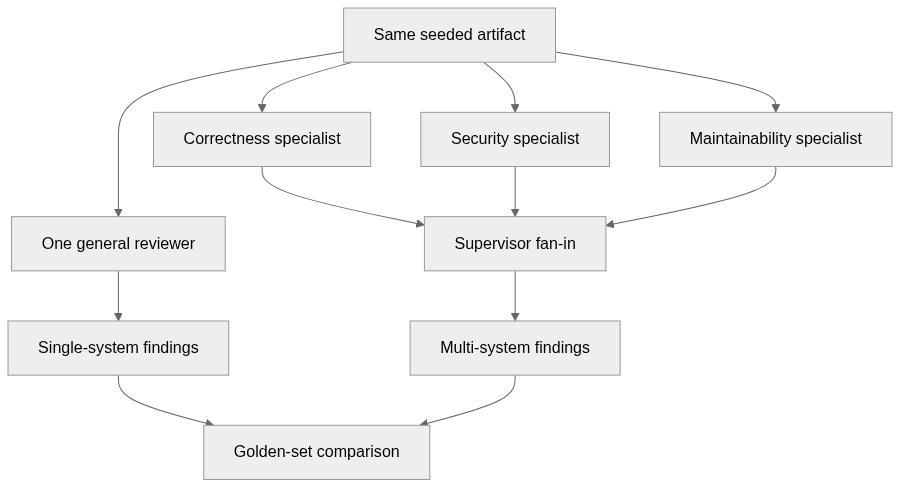

*D12 — one general reviewer and three specialists read the same artifact; both systems are scored against the golden set*

### Step 1 — Create the artifact under review

Everything today reviews this one file: deliberately defective classroom code, never to be
copied. Line numbers matter — a finding without a location cannot be checked or merged.

In [ ]:
from pathlib import Path

DATA_DIR = Path("day_04_data")          # created next to this notebook; no repository needed
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_PATH = DATA_DIR / "order_service.py"

ARTIFACT_PATH.write_text("""# Synthetic classroom artifact: it intentionally contains defects. Never copy it.

ADMIN_TOKEN = "course-demo-admin-token"


def calculate_total(items, discount_code=None, audit=[]):
    subtotal = sum(item["price"] * item["quantity"] for item in items)
    if discount_code == "STUDENT20":
        subtotal = subtotal - 20
    audit.append(subtotal)
    return subtotal


def search_orders(customer_name, database):
    query = "SELECT * FROM orders WHERE customer='" + customer_name + "'"
    return database.execute(query)


def evaluate_shipping(expression):
    return eval(expression)


def average_item_price(items):
    try:
        return sum(item["price"] for item in items) / len(items)
    except Exception:
        return 0


def create_order(user, items):
    print("creating order for", user["email"], "token", user.get("token"))
    total = calculate_total(items)
    return {"owner": user["email"], "items": items, "total": total}
""", encoding="utf-8")

SOURCE = ARTIFACT_PATH.read_text(encoding="utf-8")     # the shared, immutable artifact

for number, line in enumerate(SOURCE.splitlines(), 1):
    print(f"{number:>2}: {line}")

### Step 2 — What a finding has to contain

`Finding` is the contract every reviewer, the supervisor and the evaluator agree on. A reviewer
that cannot fill every field has an opinion, not a finding — and this record is the *only* thing
that crosses a handoff today.

In [ ]:
class Finding(BaseModel):
    """One evidenced review finding, validated the moment it is created."""
    id: str                                                   # identity of this record
    category: Literal["correctness", "security", "maintainability"]
    line: int = Field(ge=1)                                   # 1-based line in the artifact
    title: str = Field(min_length=3)                          # the claim, in one line
    evidence: str = Field(min_length=1)                       # the exact source it rests on
    severity: Literal["low", "medium", "high", "critical"]
    recommendation: str = Field(min_length=3)                 # what to change
    reviewer: str                                             # who said it

lines = SOURCE.splitlines()
example = Finding(id="EXAMPLE-1", category="security", line=3,
                  title="Credential-like token is hardcoded",
                  evidence=lines[2].strip(), severity="high",
                  recommendation="Load secrets from an injected secret store.", reviewer="you")

for name, value in example.model_dump().items():
    print(f"{name:>15}: {value}")

# The contract is enforced, not suggested: a finding with no evidence is not a finding.
try:
    Finding(id="BAD", category="security", line=3, title="Something feels wrong",
            evidence="", severity="high", recommendation="Fix it.", reviewer="you")
except ValidationError as error:
    print("\nrejected  :", error.errors()[0]["loc"][0], "-", error.errors()[0]["msg"])

### Try it yourself

Scroll back to the artifact and pick **two** defects — one `correctness`, one `maintainability`.
Write down the line number and the exact source text for each first.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
# Two defects you can find by reading alone, written as proper Finding records.
my_findings = [
    Finding(id="MINE-1", category="correctness", line=25,        # "... / len(items)"
            title="Empty item list causes division by zero",
            evidence=lines[24].strip(), severity="medium",
            recommendation="Decide what an empty order should return before dividing.",
            reviewer="student"),
    Finding(id="MINE-2", category="maintainability", line=26,    # "except Exception:"
            title="Broad exception handler hides unrelated failures",
            evidence=lines[25].strip(), severity="medium",
            recommendation="Catch only the errors you expect, and log the rest.",
            reviewer="student"),
]

for finding in my_findings:
    print(f"line {finding.line:>3} | {finding.category:<15} | {finding.severity:<6} | {finding.title}")
    print(f"         evidence: {finding.evidence}")
print("\nFindings written BEFORE seeing the answer key:", len(my_findings))

### Step 3 — Now reveal the answer key

The golden set lists every seeded defect, so we can compute **recall** and **false positives**. It
never goes into a reviewer's prompt: a reviewer shown the answers is tested on copying.

In [ ]:
GOLDEN_PATH = DATA_DIR / "golden_defects.json"
GOLDEN_PATH.write_text(json.dumps([
    {"id": "DEF-COR-01", "category": "correctness",     "line": 7,  "title": "Negative quantities are accepted",                "severity": "high"},
    {"id": "DEF-COR-02", "category": "correctness",     "line": 9,  "title": "Flat discount can make the total negative",       "severity": "medium"},
    {"id": "DEF-COR-03", "category": "correctness",     "line": 25, "title": "Empty input causes division by zero",             "severity": "medium"},
    {"id": "DEF-SEC-01", "category": "security",        "line": 3,  "title": "Credential-like token is hardcoded",              "severity": "high"},
    {"id": "DEF-SEC-02", "category": "security",        "line": 15, "title": "SQL query is built by string concatenation",      "severity": "critical"},
    {"id": "DEF-SEC-03", "category": "security",        "line": 20, "title": "Untrusted expression may reach eval",             "severity": "critical"},
    {"id": "DEF-SEC-04", "category": "security",        "line": 31, "title": "Sensitive token is written to logs",              "severity": "high"},
    {"id": "DEF-MNT-01", "category": "maintainability", "line": 6,  "title": "Mutable default argument retains state",          "severity": "medium"},
    {"id": "DEF-MNT-02", "category": "maintainability", "line": 26, "title": "Broad exception hides unrelated failures",        "severity": "medium"},
], indent=1), encoding="utf-8")

GOLDEN = json.loads(GOLDEN_PATH.read_text(encoding="utf-8"))
print("Seeded defects:", len(GOLDEN), "\n")
for category in ("correctness", "security", "maintainability"):
    in_category = [item for item in GOLDEN if item["category"] == category]
    print(f"{category} ({len(in_category)}):")
    for item in in_category:
        print(f"   line {item['line']:>3}  {item['id']}  [{item['severity']}]  {item['title']}")

### Step 4 — Score your own review

Two rules keep scoring honest: a defect is credited **once**, and a finding matching nothing is a
false positive we never quietly drop. Matching is by **location** — real reviewers invent ids.

In [ ]:
def match_to_golden(finding, line_window=1):
    """Return the id of the golden defect this finding describes, or None.
    Same category, and close enough in the file to be the same place."""
    candidates = [item for item in GOLDEN
                  if item["category"] == finding.category
                  and abs(item["line"] - finding.line) <= line_window]
    if not candidates:
        return None
    candidates.sort(key=lambda item: (abs(item["line"] - finding.line), item["id"]))
    return candidates[0]["id"]                       # nearest line wins; id breaks ties

def score(findings, line_window=1):
    """Grade a list of findings against the golden set. Each defect counts once."""
    matched, duplicates, false_positives = [], [], []
    for finding in findings:
        defect_id = match_to_golden(finding, line_window)
        if defect_id is None:
            false_positives.append(finding.id)       # matches no known defect
        elif defect_id in matched:
            duplicates.append(finding.id)            # the same defect, reported again
        else:
            matched.append(defect_id)
    expected = {item["id"] for item in GOLDEN}
    return {"known_defects": len(expected), "found": len(matched),
            "recall": round(len(matched) / len(expected), 3),
            "false_positives": len(false_positives), "duplicates": len(duplicates),
            "reported_findings": len(findings), "missed": sorted(expected - set(matched)),
            "false_positive_ids": false_positives}

my_row = score(my_findings)
for key in ("known_defects", "found", "recall", "false_positives", "duplicates", "missed"):
    print(f"{key:>15}: {my_row[key]}")

### Checkpoint

**1. Why must the golden set stay out of the reviewer's prompt?**

<details><summary>Show answer</summary>

A reviewer shown the answers is tested on copying, not on reviewing. Its recall would measure prompt leakage instead of capability.

</details>

**2. Two reviewers both report the `eval` call on line 20. How many defects were found?**

<details><summary>Show answer</summary>

One. Each defect is credited once; the second is a *duplicate*. Counting both would let a system inflate recall by repeating itself — the failure mode a team of agents risks.

</details>

### Recap

- **Limitation seen:** "the review looked thorough" is not a measurement.
- **Layer added:** a validated `Finding` contract, a hidden golden set, and location-based scoring.
- **Evidence:** two hand-written findings scored automatically, with recall and what was missed.